In [118]:
from PreRun import PreRun, PostRun
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from itertools import product
from datetime import date, datetime, timedelta

In [40]:
systems_cleaned = pd.read_csv('../../../data/core/systems_cleaned.csv')

In [41]:
name_val = (('inverter', 'inverter'), ('meter', 'meter'), ('other', 'None'))
names_list = ('inverter', 'meter', 'other')
systems_good_timezones_manual_edit = [4, 10, 33, 36, 50, 51, 1199, 1204, 1283, 1284, 1289, 1332, 4902, 4903]

In [243]:
nice_system_data = systems_cleaned[systems_cleaned.system_id.isin(systems_good_timezones_manual_edit)]

In [251]:
nice_system_data[['system_id', 'dc_capacity_kW', 'latitude', 'longitude', 'tilt', 'azimuth']]

,system_id,dc_capacity_kW,latitude,longitude,tilt,azimuth
2,4,1.000,39.7406,-105.1774,40.00,180.0
3,10,1.120,39.7404,-105.1774,40.00,180.0
4,33,2.400,39.7404,-105.1772,40.00,180.0
7,36,2.210,39.7040,-105.1773,45.00,180.0
8,50,6.000,39.7420,-105.1727,45.00,158.0
9,51,6.000,39.7416,-105.1734,45.00,158.0
10,1199,52.920,39.4856,-76.6636,20.00,180.0
15,1204,78.645,39.8256,-75.3828,5.00,140.0
68,1283,408.240,39.7409,-105.1711,10.00,165.0
69,1284,1.200,39.7405,-105.1774,40.00,180.0


In [42]:
def nighttime_data(system_id, path, met_or_inv, systems_cleaned, pct):
    all_data = PreRun(system_id=system_id, path=path,
                      meter_or_inverter=met_or_inv,
                      systems_cleaned=systems_cleaned)
    all_data.add_weather_features_only()
    local_data = all_data.amended_data.copy(deep=True)
    night_data = local_data[
        (local_data['global_tilted_irradiance'] == 0)
        & (local_data['proportion_daytime'] == 0)
    ]
    if pct is None:
        return night_data
    else:
        my_systems = systems_cleaned[systems_cleaned['system_id'] == system_id]
        first_ind = my_systems.index[0]
        nominal_capacity = my_systems.at[first_ind, 'dc_capacity_kW']
        return night_data[night_data['energy'] > (pct / 100 * nominal_capacity)]


## System 4

In [43]:
nighttime_data(
    4, './clean_again/', None, systems_cleaned, 70
)

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime
33074,2019-12-16 18:00:00,0.72635,0.00,0.0,0.0
33075,2019-12-16 19:00:00,0.72635,0.00,0.0,0.0
33076,2019-12-16 20:00:00,0.72635,0.00,0.0,0.0
33077,2019-12-16 21:00:00,0.72635,0.00,0.0,0.0
33078,2019-12-16 22:00:00,0.72635,0.00,0.0,0.0
33079,2019-12-16 23:00:00,0.72635,0.01,0.0,0.0


## System 36

In [44]:
night_36 = nighttime_data(
    36, './clean_again/', None, systems_cleaned, None
)

In [250]:
night_36.iloc[60:80]

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime
11886,2016-10-14 02:00:00,0.026999,0.00,0.0,0.0
11887,2016-10-14 03:00:00,0.026811,0.00,0.0,0.0
11888,2016-10-14 04:00:00,0.026572,0.00,0.0,0.0
11889,2016-10-14 05:00:00,0.026725,0.00,0.0,0.0
11903,2016-10-14 19:00:00,0.026313,0.92,0.0,0.0
11904,2016-10-14 20:00:00,0.026172,0.95,0.0,0.0
11905,2016-10-14 21:00:00,0.026337,0.76,0.0,0.0
11906,2016-10-14 22:00:00,0.026322,0.54,0.0,0.0
11907,2016-10-14 23:00:00,0.026291,0.16,0.0,0.0
11908,2016-10-15 00:00:00,0.026383,0.17,0.0,0.0


## System 50  (6 kW[h])

In [258]:
night_50 = nighttime_data(
    50, './clean_again/', None, systems_cleaned, 0.01
)
night_50.head()

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime
34285,2008-11-02 05:00:00,0.098877,0.08,0.0,0.0
35472,2009-03-17 19:00:00,0.019354,0.00,0.0,0.0
35508,2009-03-20 19:00:00,0.034377,0.50,0.0,0.0


These are all edge-of-good anyways!

In [255]:
night_50_wide = nighttime_data(
    50, './clean_again/', None, systems_cleaned, None
)
night_50_wide.head()

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime
26630,2006-01-01 00:00:00,0.000005,1.00,0.0,0.0
26631,2006-01-01 01:00:00,0.000004,1.00,0.0,0.0
26632,2006-01-01 02:00:00,0.000005,1.00,0.0,0.0
26633,2006-01-01 03:00:00,0.000004,1.00,0.0,0.0
26634,2006-01-01 04:00:00,0.000005,0.84,0.0,0.0


## Systems 1199, 1204

(Bad gti, daylight rules)

In [262]:
all_nighttime = nighttime_data(
    1199, './clean_again/', 'inverter', systems_cleaned, None
)
all_nighttime['hour'] = all_nighttime['time'].dt.hour
all_nighttime['hour'].value_counts()

hour
9     2275
10    2275
11    2275
12    2275
13    2275
8     2272
7     2130
14    1731
15    1052
6      938
16     436
Name: count, dtype: int64

In [263]:
all_nighttime.head()

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime,hour
2,2010-05-29 07:00:00,6.820578,0.86,0.0,0.0,7
3,2010-05-29 08:00:00,16.192074,0.88,0.0,0.0,8
4,2010-05-29 09:00:00,13.899535,0.99,0.0,0.0,9
5,2010-05-29 10:00:00,16.112157,1.00,0.0,0.0,10
6,2010-05-29 11:00:00,23.473406,1.00,0.0,0.0,11


## System 1283  (408 kW[h])

In [275]:
night_1283_i = nighttime_data(
    1283, './clean_again/', 'inverter', systems_cleaned, None
)
night_1283_i.head()

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime
23395,2021-05-19 20:00:00,3.442328,0.06,0.0,0.0
23409,2021-05-20 20:00:00,2.700467,0.00,0.0,0.0
23423,2021-05-21 20:00:00,4.907490,0.25,0.0,0.0
23437,2021-05-22 20:00:00,0.733153,0.95,0.0,0.0
23451,2021-05-23 20:00:00,3.174445,0.00,0.0,0.0


In [278]:
night_1283_i.sort_values(['energy'], ascending=False).head()

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime,hour
26146,2022-01-24 18:00:00,13.568508,0.92,0.0,0.0,18
24900,2021-09-11 19:00:00,12.578307,0.78,0.0,0.0,19
25321,2021-10-20 18:00:00,12.328168,1.00,0.0,0.0,18
26136,2022-01-23 18:00:00,11.739598,0.00,0.0,0.0,18
26126,2022-01-22 18:00:00,10.881623,0.25,0.0,0.0,18


In [279]:
night_1283_i['hour'] = night_1283_i['time'].dt.hour
night_1283_i['hour'].value_counts().sort_index()

hour
18    82
19    28
20    39
21    15
Name: count, dtype: int64

In [271]:
len(night_1283_i)

83

In [272]:
night_1283_i['energy'].describe()

count    83.000000
mean      4.945951
std       2.673186
min       2.055055
25%       3.158850
50%       4.211220
75%       5.465494
max      13.568508
Name: energy, dtype: float64

In [273]:
night_1283_m = nighttime_data(
    1283, './clean_again/', 'meter', systems_cleaned, None
)
night_1283_m.head()

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime
23639,2021-05-19 20:00:00,6.934167,0.06,0.0,0.0
23653,2021-05-20 20:00:00,5.646667,0.00,0.0,0.0
23667,2021-05-21 20:00:00,9.776667,0.25,0.0,0.0
23681,2021-05-22 20:00:00,2.513750,0.95,0.0,0.0
23695,2021-05-23 20:00:00,6.423750,0.00,0.0,0.0


In [274]:
night_1283_m['hour'] = night_1283_m['time'].dt.hour
night_1283_m['hour'].value_counts()

hour
18    82
20    39
19    29
21    18
Name: count, dtype: int64

In [51]:
all_nighttime['global_tilted_irradiance'].value_counts()

global_tilted_irradiance
0.0    19934
Name: count, dtype: int64

In [52]:
all_nighttime['proportion_daytime'].value_counts()

proportion_daytime
0.0    19934
Name: count, dtype: int64

## SYstem 1289  (1.82 kW)

In [286]:
night_1289 = nighttime_data(
    1289, './clean_again/', None, systems_cleaned, None
)

In [288]:
night_1289.head(7)

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime
5012,2014-07-19 21:00:00,0.179372,0.02,0.0,0.0
5013,2014-07-19 22:00:00,0.179372,0.00,0.0,0.0
5014,2014-07-19 23:00:00,0.179372,0.00,0.0,0.0
5015,2014-07-20 00:00:00,0.179372,0.00,0.0,0.0
5016,2014-07-20 01:00:00,0.179372,0.00,0.0,0.0
5017,2014-07-20 02:00:00,0.179372,0.00,0.0,0.0
5018,2014-07-20 03:00:00,0.179372,0.00,0.0,0.0


In [285]:
night_1289.tail(6)

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime,hour,date
19010,2019-12-16 18:00:00,1.146389,0.00,0.0,0.0,18,2019-12-16
19011,2019-12-16 19:00:00,1.146389,0.00,0.0,0.0,19,2019-12-16
19012,2019-12-16 20:00:00,1.146389,0.00,0.0,0.0,20,2019-12-16
19013,2019-12-16 21:00:00,1.146389,0.00,0.0,0.0,21,2019-12-16
19014,2019-12-16 22:00:00,1.146389,0.00,0.0,0.0,22,2019-12-16
19015,2019-12-16 23:00:00,1.146389,0.01,0.0,0.0,23,2019-12-16


In [281]:
night_1289['hour'] = night_1289['time'].dt.hour

In [283]:
night_1289['date'] = night_1289['time'].dt.date
night_1289['date'].value_counts()

date
2019-12-16    6
2014-07-20    4
2014-07-19    3
Name: count, dtype: int64

In [282]:
night_1289['hour'].value_counts()

hour
21    2
22    2
23    2
0     1
1     1
2     1
3     1
18    1
19    1
20    1
Name: count, dtype: int64

## System 4903 (73.7 kW))

In [300]:
night_4903_i = nighttime_data(
    4903, './clean_again/', 'inverter', systems_cleaned, None
)

In [302]:
night_4903_i.iloc[10:20]

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime
26,2014-08-03 02:00:00,6.5,0.88,0.0,0.0
27,2014-08-03 03:00:00,6.5,0.77,0.0,0.0
28,2014-08-03 04:00:00,6.5,0.85,0.0,0.0
45,2014-08-03 21:00:00,6.5,0.38,0.0,0.0
46,2014-08-03 22:00:00,6.5,0.27,0.0,0.0
47,2014-08-03 23:00:00,6.5,0.41,0.0,0.0
48,2014-08-08 00:00:00,51.7,0.00,0.0,0.0
49,2014-08-08 01:00:00,51.7,0.01,0.0,0.0
50,2014-08-08 02:00:00,51.7,0.05,0.0,0.0
51,2014-08-08 03:00:00,51.7,0.12,0.0,0.0


In [299]:
night_4903_i.iloc[49:]

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime
172,2014-08-13 04:00:00,51.7,0.24,0.0,0.0


In [307]:
night_4903_m = nighttime_data(
    4903, './clean_again/', 'meter', systems_cleaned, None
)

In [309]:
night_4903_m.iloc[0:10]

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime
0,2014-08-02 00:00:00,6.695,1.00,0.0,0.0
1,2014-08-02 01:00:00,6.695,1.00,0.0,0.0
2,2014-08-02 02:00:00,6.695,0.99,0.0,0.0
3,2014-08-02 03:00:00,6.695,0.90,0.0,0.0
4,2014-08-02 04:00:00,6.695,0.88,0.0,0.0
21,2014-08-02 21:00:00,6.695,1.00,0.0,0.0
22,2014-08-02 22:00:00,6.695,1.00,0.0,0.0
23,2014-08-02 23:00:00,6.695,1.00,0.0,0.0
24,2014-08-03 00:00:00,6.695,1.00,0.0,0.0
25,2014-08-03 01:00:00,6.695,1.00,0.0,0.0


In [312]:
night_4903_m.iloc[30:]

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime
188,2014-08-30 21:00:00,19.47,1.00,0.0,0.0
189,2014-08-30 22:00:00,19.47,0.98,0.0,0.0
190,2014-08-30 23:00:00,19.47,0.95,0.0,0.0


In [ ]:
nighttime_maxes = {
    system_id: {
        name[0]: [0, 0] for name in name_val
    } for system_id in systems_good_timezones_manual_edit
}
for system_id, (name, val) in product(systems_good_timezones_manual_edit, name_val):
    try:
        data_pq = pq.ParquetDataset(
            f'./test_results/{system_id}-{val}/{name}/{system_id}'
        )
        good_days_df = pd.read_csv(
            f'./test_results/{system_id}-{val}/good_days/{system_id}_good_days_{name}.csv'
        )
    except FileNotFoundError:
        nighttime_maxes[system_id].pop(name)
        continue
    if val == 'None':
        real_val = None
    else:
        real_val = val
    prerun_system = PreRun(system_id, f'./test_results/{system_id}-{val}/', real_val, systems_cleaned)
    prerun_system.add_weather_features_only()
    nighttime_data = prerun_system.amended_data[
        (prerun_system.amended_data['proportion_daytime'] == 0)
        & (prerun_system.amended_data['global_tilted_irradiance'] == 0)
    ]
    nighttime_max = nighttime_data['energy'].max()
    my_system = systems_cleaned[systems_cleaned['system_id'] == system_id]
    first_ind = my_system.index[0]
    system_max = systems_cleaned.at[first_ind, 'dc_capacity_kW']
    nighttime_maxes[system_id][name][0] = nighttime_max / system_max
    nighttime_maxes[system_id][name][1] = len(nighttime_data)
    print(f'System {system_id}, reader {name}:')
    print(f'Of {nighttime_maxes[system_id][name][1]} relevant rows, '
          + f'max entry is {nighttime_maxes[system_id][name][0] * 100:.2f}% of nominal capacity.')
    # prevent stall
    sleep(20)

In [ ]:
nighttime_medians = {
    system_id: {
        name[0]: [0, 0] for name in name_val
    } for system_id in systems_good_timezones_manual_edit
}
for system_id, (name, val) in product(systems_good_timezones_manual_edit, name_val):
    try:
        data_pq = pq.ParquetDataset(
            f'./test_results/{system_id}-{val}/{name}/{system_id}'
        )
        good_days_df = pd.read_csv(
            f'./test_results/{system_id}-{val}/good_days/{system_id}_good_days_{name}.csv'
        )
    except FileNotFoundError:
        nighttime_medians[system_id].pop(name)
        continue
    if val == 'None':
        real_val = None
    else:
        real_val = val
    prerun_system = PreRun(system_id, f'./test_results/{system_id}-{val}/', real_val, systems_cleaned)
    prerun_system.add_weather_features_only()
    nighttime_data = prerun_system.amended_data[
        (prerun_system.amended_data['proportion_daytime'] == 0)
        & (prerun_system.amended_data['global_tilted_irradiance'] == 0)
    ]
    nighttime_median = nighttime_data['energy'].median()
    my_system = systems_cleaned[systems_cleaned['system_id'] == system_id]
    first_ind = my_system.index[0]
    system_max = systems_cleaned.at[first_ind, 'dc_capacity_kW']
    nighttime_medians[system_id][name][0] = nighttime_median / system_max
    nighttime_medians[system_id][name][1] = len(nighttime_data)
    print(f'System {system_id}, reader {name}:')
    print(f'Of {nighttime_medians[system_id][name][1]} relevant rows, '
          + f'median entry is {nighttime_medians[system_id][name][0] * 100:.2f}% of nominal capacity.')
    # prevent stall
    sleep(20)

In [228]:
test_offset = PreRun(4, './clean_again/', None, systems_cleaned)
test_offset.add_weather_features_only()
off_check = test_offset.amended_data.copy(deep=True)

In [230]:
test_offset.good_end_days_naive(streak=7)
test_offset.end_days_naive[0:10]

,date
0,2007-10-01
1,2007-10-02
2,2007-10-03
3,2007-10-04
4,2007-10-05
5,2007-10-06
6,2007-10-28
7,2007-10-29
8,2007-10-30
9,2007-10-31


In [24]:
off_check.iloc[20:40]

,time,energy,cloud_cover,global_tilted_irradiance,proportion_daytime
20,2007-09-03 14:00:00,0.713004,0.54,881.405579,1.000000
21,2007-09-03 15:00:00,0.384886,0.76,658.697754,1.000000
22,2007-09-03 16:00:00,0.060093,0.70,444.037933,1.000000
23,2007-09-03 17:00:00,0.027858,0.61,250.545654,1.000000
24,2007-09-03 18:00:00,0.003123,0.67,106.279007,0.491389
25,2007-09-04 06:00:00,0.032368,0.00,3.719253,1.000000
26,2007-09-04 07:00:00,0.236269,0.00,108.752510,1.000000
27,2007-09-04 08:00:00,0.470191,0.00,348.762360,1.000000
28,2007-09-04 09:00:00,0.657658,0.04,596.247559,1.000000
29,2007-09-04 10:00:00,0.793747,0.20,782.194580,1.000000


## Check offsets of OpenMeteoData

In [57]:
system_4_raw_pq = pq.ParquetDataset(
    '../../../../data_ds_project/testing_yearly_parquet/4'
)

In [58]:
system_4_raw_df = system_4_raw_pq.read().to_pandas()

In [66]:
systems_cleaned[systems_cleaned['system_id'] == 4][['tilt', 'azimuth']]

,tilt,azimuth
2,40.0,180.0


In [67]:
systems_cleaned['azimuth'].max()

np.float64(315.0)

In [61]:
system_4_raw_df['time'] = system_4_raw_df['time'].dt.tz_localize('Etc/GMT+7')

In [62]:
system_4_raw_df['date'] = system_4_raw_df['time'].dt.date

In [64]:
system_4_raw_df['date'].min()

datetime.date(2007, 8, 26)

In [65]:
system_4_raw_df.head()

,time,ac_power_kW,year,date
0,2007-08-26 00:00:00-07:00,-0.000006,2007,2007-08-26
1,2007-08-26 00:15:00-07:00,-0.000029,2007,2007-08-26
2,2007-08-26 00:30:00-07:00,-0.000029,2007,2007-08-26
3,2007-08-26 00:45:00-07:00,-0.000020,2007,2007-08-26
4,2007-08-26 01:00:00-07:00,-0.000021,2007,2007-08-26


In [68]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

In [69]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 39.7406,
	"longitude": -105.1774,
	"start_date": "2007-08-26",
	"end_date": "2023-02-28",
	"daily": ["sunrise", "sunset"],
	"hourly": ["cloud_cover", "global_tilted_irradiance", "global_tilted_irradiance_instant"],
	"timezone": "GMT",
	"tilt": 40,
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_cloud_cover = hourly.Variables(0).ValuesAsNumpy()
hourly_global_tilted_irradiance = hourly.Variables(1).ValuesAsNumpy()
hourly_global_tilted_irradiance_instant = hourly.Variables(2).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["cloud_cover"] = hourly_cloud_cover
hourly_data["global_tilted_irradiance"] = hourly_global_tilted_irradiance
hourly_data["global_tilted_irradiance_instant"] = hourly_global_tilted_irradiance_instant

hourly_dataframe = pd.DataFrame(data = hourly_data)

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_sunrise = daily.Variables(0).ValuesInt64AsNumpy()
daily_sunset = daily.Variables(1).ValuesInt64AsNumpy()

daily_data = {
	"date": pd.date_range(
		start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = daily.Interval()),
		inclusive = "left"
	)
}

daily_data["sunrise"] = daily_sunrise
daily_data["sunset"] = daily_sunset

daily_dataframe = pd.DataFrame(data = daily_data)

Coordinates: 39.75395202636719°N -105.14604187011719°E
Elevation: 1788.0 m asl
Timezone: NoneNone
Timezone difference to GMT+0: 0s


In [73]:
hourly_dataframe = hourly_dataframe.rename(columns={'date':'time'})
hourly_dataframe['time'] = hourly_dataframe['time'].dt.tz_convert('Etc/GMT+7')

In [75]:
hourly_dataframe['date'] = hourly_dataframe['time'].dt.date

In [76]:
hourly_dataframe.head()

,time,cloud_cover,global_tilted_irradiance,global_tilted_irradiance_instant,date
0,2007-08-25 17:00:00-07:00,37.0,294.213379,228.538513,2007-08-25
1,2007-08-25 18:00:00-07:00,2.0,123.964317,69.656998,2007-08-25
2,2007-08-25 19:00:00-07:00,0.0,10.298133,0.000000,2007-08-25
3,2007-08-25 20:00:00-07:00,0.0,0.000000,0.000000,2007-08-25
4,2007-08-25 21:00:00-07:00,0.0,0.000000,0.000000,2007-08-25


In [182]:
sample_day_energy = system_4_raw_df[system_4_raw_df['date'] == date(2007,9,1)].copy(deep=True)
sample_day_weather = hourly_dataframe[hourly_dataframe['date'] == date(2007, 9, 1)].copy(deep=True)

In [183]:
sample_day_energy['power_pct'] = sample_day_energy['ac_power_kW'] / sample_day_energy['ac_power_kW'].max()*100
sample_day_energy['power_pct'] = sample_day_energy.apply(
    lambda row: row['power_pct'] if row['power_pct'] > 0 else 0,
    axis=1
)
sample_day_weather['gti_pct'] = sample_day_weather['global_tilted_irradiance']/sample_day_weather['global_tilted_irradiance'].max() * 100
sample_day_weather['gti_inst'] = sample_day_weather['global_tilted_irradiance_instant']/sample_day_weather['global_tilted_irradiance_instant'].max() * 100

In [186]:
sample_day_weather['gti_offset'] = sample_day_weather['gti_pct'].shift(-1)
sample_day_weather.iloc[10:20]

,time,cloud_cover,global_tilted_irradiance,global_tilted_irradiance_instant,date,gti_pct,gti_inst,gti_offset
161,2007-09-01 10:00:00-07:00,34.0,737.446045,798.418884,2007-09-01,79.491608,85.162300,91.425339
162,2007-09-01 11:00:00-07:00,49.0,848.155579,884.852600,2007-09-01,91.425339,94.381645,100.000000
163,2007-09-01 12:00:00-07:00,48.0,927.703003,937.526184,2007-09-01,100.000000,100.000000,95.921677
164,2007-09-01 13:00:00-07:00,62.0,889.868286,871.933655,2007-09-01,95.921677,93.003662,79.325470
165,2007-09-01 14:00:00-07:00,66.0,735.904724,697.122192,2007-09-01,79.325470,74.357620,60.952133
166,2007-09-01 15:00:00-07:00,90.0,565.454773,513.548218,2007-09-01,60.952133,54.776947,37.580055
167,2007-09-01 16:00:00-07:00,95.0,348.631287,297.485046,2007-09-01,37.580055,31.730852,21.700455
168,2007-09-01 17:00:00-07:00,74.0,201.315781,152.208481,2007-09-01,21.700455,16.235117,8.483091
169,2007-09-01 18:00:00-07:00,55.0,78.697891,37.948185,2007-09-01,8.483091,4.047693,0.593799
170,2007-09-01 19:00:00-07:00,50.0,5.508693,0.000000,2007-09-01,0.593799,0.000000,0.000000


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

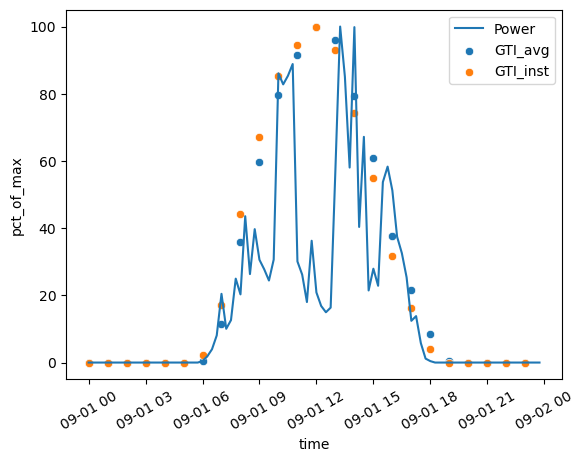

In [96]:
sns.lineplot(sample_day_energy, x='time', y='power_pct', label='Power')
sns.scatterplot(sample_day_weather, x='time', y='gti_pct', label='GTI_avg')
sns.scatterplot(sample_day_weather, x='time', y='gti_inst', label='GTI_inst')
plt.ylabel('pct_of_max')
plt.xticks(rotation=30)
plt.show()

In [104]:
def graph_one_day(date_of_interest: date):
    energy_on_date = system_4_raw_df[system_4_raw_df['date']==date_of_interest].copy(deep=True)
    irradiance_on_date = hourly_dataframe[hourly_dataframe['date']==date_of_interest].copy(deep=True)
    energy_on_date['power_pct'] = energy_on_date['ac_power_kW'] / energy_on_date['ac_power_kW'].max()*100
    energy_on_date['power_pct'] = energy_on_date.apply(
        lambda row: row['power_pct'] if row['power_pct'] > 0 else 0,
        axis=1
    )
    irradiance_on_date['gti_pct'] = irradiance_on_date['global_tilted_irradiance']/irradiance_on_date['global_tilted_irradiance'].max() * 100
    irradiance_on_date['gti_inst'] = irradiance_on_date['global_tilted_irradiance_instant']/irradiance_on_date['global_tilted_irradiance_instant'].max() * 100
    fig = plt.Figure(figsize=(8, 6))
    sns.lineplot(energy_on_date, x='time', y='power_pct', label='Power')
    sns.scatterplot(irradiance_on_date, x='time', y='gti_pct', label='GTI_avg')
    sns.scatterplot(irradiance_on_date, x='time', y='gti_inst', label='GTI_inst')
    plt.ylabel('pct_of_max')
    plt.xticks(rotation=30)
    return fig


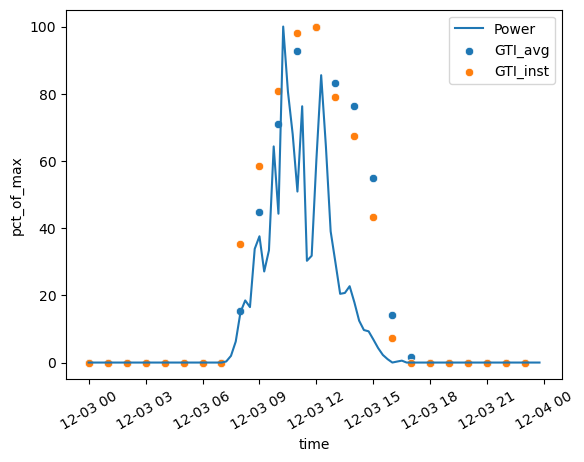

In [105]:
graph_one_day(date(2007,12, 3))
plt.show()

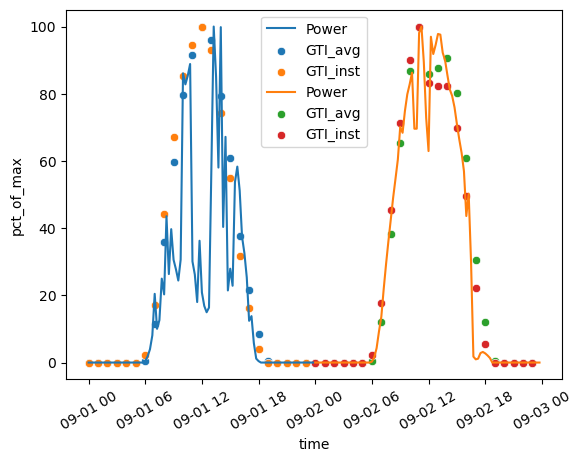

In [110]:
graph_one_day(date(2007,9, 1))
graph_one_day(date(2007,9, 2))
plt.show()

In [114]:
def graph_several_days(df_energy, df_weather, start_date: date, end_date: date):
    energy_on_date = df_energy[
        (df_energy['date']>=start_date)
        & (df_energy['date'] <= end_date)
    ].copy(deep=True)
    irradiance_on_date = df_weather[
        (df_weather['date']>=start_date)
        & (df_weather['date'] <= end_date)
    ].copy(deep=True)
    energy_on_date['power_pct'] = energy_on_date['ac_power_kW'] / energy_on_date['ac_power_kW'].max()*100
    energy_on_date['power_pct'] = energy_on_date.apply(
        lambda row: row['power_pct'] if row['power_pct'] > 0 else 0,
        axis=1
    )
    irradiance_on_date['gti_pct'] = irradiance_on_date['global_tilted_irradiance']/irradiance_on_date['global_tilted_irradiance'].max() * 100
    irradiance_on_date['gti_inst'] = irradiance_on_date['global_tilted_irradiance_instant']/irradiance_on_date['global_tilted_irradiance_instant'].max() * 100
    num_days = (end_date - start_date).days + 1
    fig = plt.Figure(figsize=(6*num_days, 6))
    sns.lineplot(energy_on_date, x='time', y='power_pct', label='Power')
    sns.scatterplot(irradiance_on_date, x='time', y='gti_pct', label='GTI_avg')
    sns.scatterplot(irradiance_on_date, x='time', y='gti_inst', label='GTI_inst')
    plt.ylabel('pct_of_max')
    plt.xticks(rotation=30)
    return fig

In [126]:
def graph_one_day_b(df_energy, df_weather, date_of_interest: date):
    energy_on_date = df_energy[df_energy['date']==date_of_interest].copy(deep=True)
    irradiance_on_date = df_weather[df_weather['date']==date_of_interest].copy(deep=True)
    energy_on_date['power_pct'] = energy_on_date['ac_power_kW'] / energy_on_date['ac_power_kW'].max()*100
    energy_on_date['power_pct'] = energy_on_date.apply(
        lambda row: row['power_pct'] if row['power_pct'] > 0 else 0,
        axis=1
    )
    irradiance_on_date['gti_pct'] = irradiance_on_date['global_tilted_irradiance']/irradiance_on_date['global_tilted_irradiance'].max() * 100
    irradiance_on_date['gti_inst'] = irradiance_on_date['global_tilted_irradiance_instant']/irradiance_on_date['global_tilted_irradiance_instant'].max() * 100
    fig, ax = plt.subplots()
    sns.lineplot(energy_on_date, x='time', y='power_pct', label='Power')
    sns.scatterplot(irradiance_on_date, x='time', y='gti_pct', label='GTI_avg')
    sns.scatterplot(irradiance_on_date, x='time', y='gti_inst', label='GTI_inst')
    plt.ylabel('pct_of_max')
    plt.xticks(rotation=30)
    return ax

In [129]:
def graph_several_days_b(df_energy, df_weather, start_date: date, end_date: date):
    num_days = (end_date - start_date).days + 1
    fig, axs = plt.subplots(nrows=num_days)
    for j in range(num_days):
        the_date = start_date + timedelta(days=j)
        axs[j] = graph_one_day_b(df_energy, df_weather, the_date)
    return fig

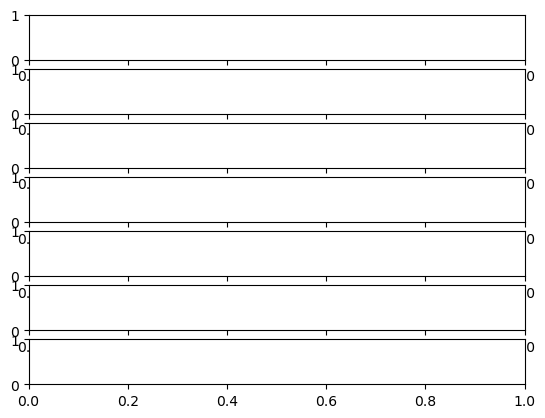

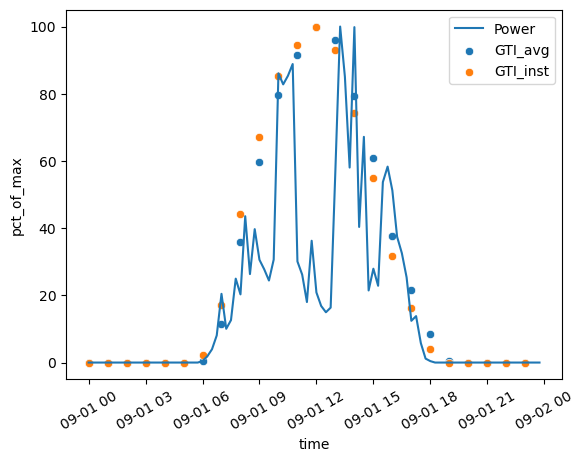

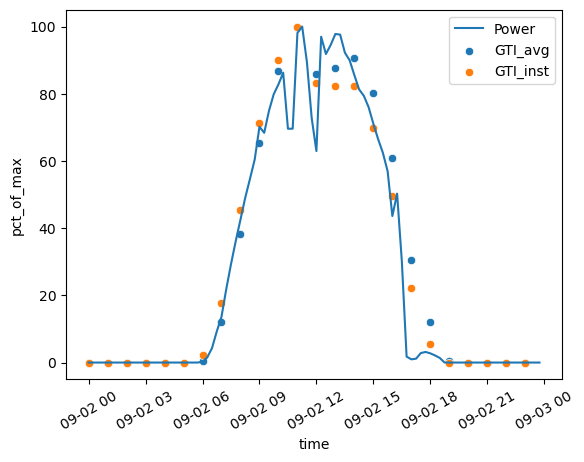

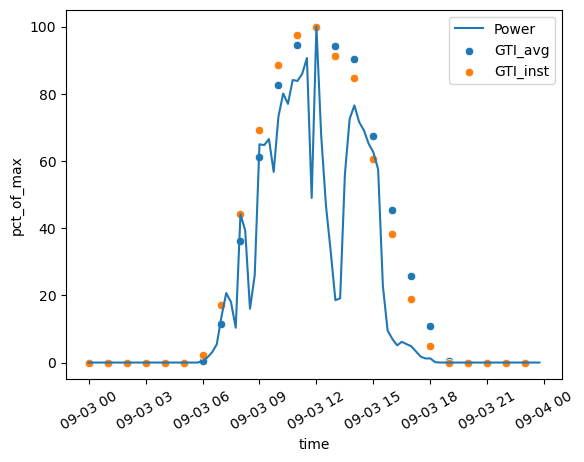

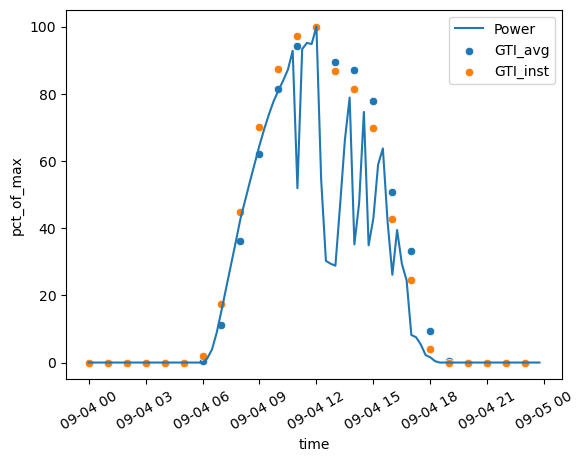

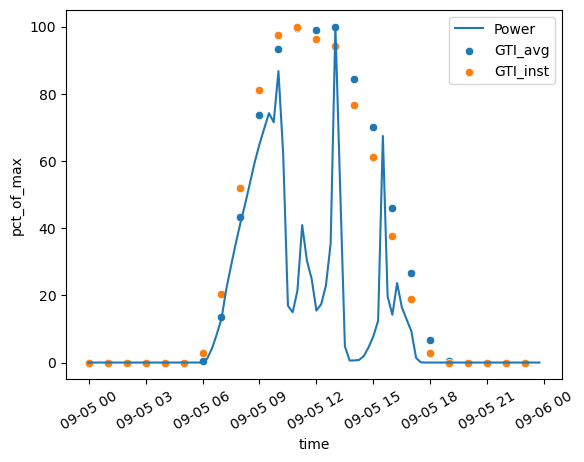

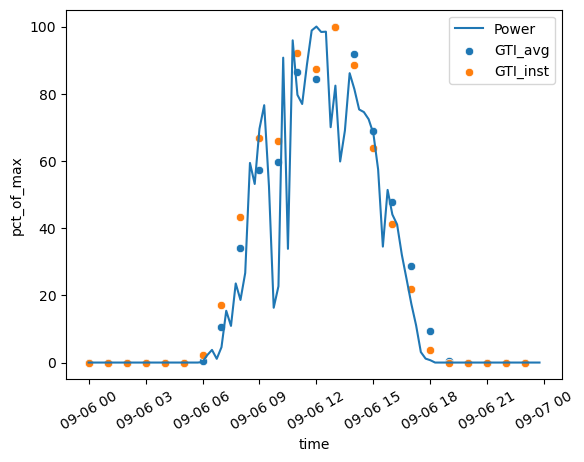

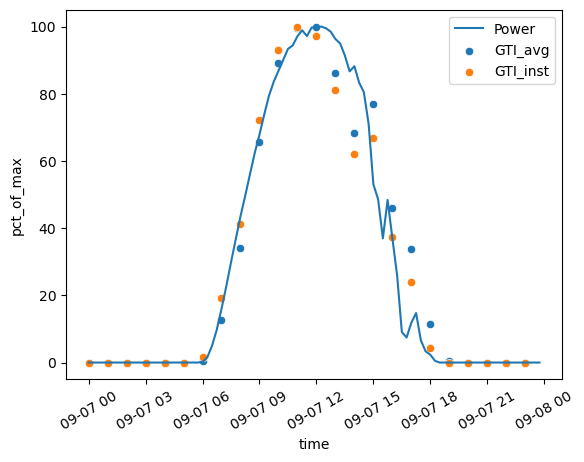

In [130]:
graph_several_days_b(system_4_raw_df, hourly_dataframe, date(2007, 9, 1), date(2007, 9, 7))
plt.show()

In [194]:
def transformed_data_on_date(df_energy, df_weather, date_of_interest):
    energy_on_date = df_energy[df_energy['date']==date_of_interest].copy(deep=True)
    energy_on_date = energy_on_date[['time', 'ac_power_kW']]
    energy_on_date['ac_power_kW'] = energy_on_date.apply(
        lambda row: row['ac_power_kW'] if row['ac_power_kW'] > 0 else 0,
        axis=1
    )
    irradiance_on_date = df_weather[df_weather['date']==date_of_interest].copy(deep=True)
    irradiance_on_date = irradiance_on_date[['time', 'global_tilted_irradiance', 'global_tilted_irradiance_instant']]
    irradiance_on_date['global_tilted_irradiance_early'] = irradiance_on_date['global_tilted_irradiance'].shift(-1)
    combined_data = pd.merge(energy_on_date, irradiance_on_date, how='outer', left_on = 'time', right_on='time')
    # since average over prior hour, fill *back*
    combined_data['gti_fill'] = combined_data['global_tilted_irradiance'].bfill()
    # but need to fill the last hour
    combined_data['gti_fill'] = combined_data['gti_fill'].ffill()
    # for shifted, do the opposite
    combined_data['gti_early_fill'] = combined_data['global_tilted_irradiance_early'].ffill()
    combined_data['gti_early_fill'] = combined_data['gti_early_fill'].bfill()
    # for instant gti, fill nearest
    combined_data['gti_inst_fill'] = combined_data['global_tilted_irradiance_instant'].interpolate('nearest')
    combined_data = combined_data[['time', 'ac_power_kW',
                                   'global_tilted_irradiance', 'gti_fill',
                                   'global_tilted_irradiance_early', 'gti_early_fill',
                                   'global_tilted_irradiance_instant', 'gti_inst_fill']]
    return combined_data


In [195]:
combo_nine_oh_one = transformed_data_on_date(system_4_raw_df, hourly_dataframe, date(2007,9,1))

In [196]:
combo_nine_oh_one.iloc[10:30]

,time,ac_power_kW,global_tilted_irradiance,gti_fill,global_tilted_irradiance_early,gti_early_fill,global_tilted_irradiance_instant,gti_inst_fill
10,2007-09-01 02:30:00-07:00,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
11,2007-09-01 02:45:00-07:00,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
12,2007-09-01 03:00:00-07:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
13,2007-09-01 03:15:00-07:00,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
14,2007-09-01 03:30:00-07:00,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
15,2007-09-01 03:45:00-07:00,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
16,2007-09-01 04:00:00-07:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
17,2007-09-01 04:15:00-07:00,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
18,2007-09-01 04:30:00-07:00,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
19,2007-09-01 04:45:00-07:00,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000


In [201]:
def rescaled_data_on_date(df_energy, df_weather, date_of_interest, add_fill):
    combined_data_in = transformed_data_on_date(df_energy, df_weather, date_of_interest)
    combined_data_out = combined_data_in.copy(deep=True)
    if add_fill:
        combined_data_out['relative_power'] = combined_data_out['ac_power_kW']\
            / combined_data_out['ac_power_kW'].max() * 100
        combined_data_out['relative_gti_past'] = combined_data_out['gti_fill']\
            / combined_data_out['gti_fill'].max() * 100
        combined_data_out['relative_gti_future'] = combined_data_out['gti_early_fill']\
            / combined_data_out['gti_early_fill'].max() * 100
        combined_data_out['relative_gti_inst'] = combined_data_out['gti_inst_fill']\
            / combined_data_out['gti_inst_fill'].max() * 100
    else:
        combined_data_out['relative_power'] = combined_data_out['ac_power_kW']\
            / combined_data_out['ac_power_kW'].max() * 100
        combined_data_out['relative_gti_past'] = combined_data_out['global_tilted_irradiance']\
            / combined_data_out['global_tilted_irradiance'].max() * 100
        combined_data_out['relative_gti_inst'] = combined_data_out['global_tilted_irradiance_instant']\
            / combined_data_out['global_tilted_irradiance_instant'].max() * 100
        combined_data_out['relative_gti_future'] = combined_data_out['global_tilted_irradiance_early']\
            / combined_data_out['global_tilted_irradiance_early'].max() * 100
    combined_data_out = combined_data_out[['time', 'relative_power', 'relative_gti_future', 'relative_gti_inst', 'relative_gti_past']]
    return combined_data_out

In [202]:
rescaled_data_on_date(system_4_raw_df, hourly_dataframe, date(2007,9,2), False)

,time,relative_power,relative_gti_future,relative_gti_inst,relative_gti_past
0,2007-09-02 00:00:00-07:00,0.0,0.0,0.0,0.0
1,2007-09-02 00:15:00-07:00,0.0,NaN,NaN,NaN
2,2007-09-02 00:30:00-07:00,0.0,NaN,NaN,NaN
3,2007-09-02 00:45:00-07:00,0.0,NaN,NaN,NaN
4,2007-09-02 01:00:00-07:00,0.0,0.0,0.0,0.0
...,...,...,...,...,...
91,2007-09-02 22:45:00-07:00,0.0,NaN,NaN,NaN
92,2007-09-02 23:00:00-07:00,0.0,NaN,0.0,0.0
93,2007-09-02 23:15:00-07:00,0.0,NaN,NaN,NaN
94,2007-09-02 23:30:00-07:00,0.0,NaN,NaN,NaN


In [215]:
def graph_several_days_c(df_energy: pd.DataFrame, df_weather: pd.DataFrame,
                         add_fill: bool,
                         start_date: date, end_date: date):
    num_days = (end_date - start_date).days + 1
    fig, axs = plt.subplots(nrows=num_days, figsize=(8,6*num_days), sharex=False,sharey=False)
    for j in range(num_days):
        the_date = start_date + timedelta(days=j)
        total_data = rescaled_data_on_date(df_energy, df_weather, the_date, add_fill)
        if add_fill:
            sns.lineplot(total_data, x='time', y='relative_power',
                         color='blue', ax=axs[j], label='Power (relative to maximum)')
            sns.lineplot(total_data,x='time', y='relative_gti_past',
                         color='green', ax=axs[j], label='GTI (past-hour average)')
            sns.lineplot(total_data, x='time', y='relative_gti_inst',
                         color='orange', ax=axs[j], label = 'GTI (closest instantaneous reading)')
        else:
            sns.lineplot(total_data, x='time', y='relative_power',
                         color='blue',
                         ax=axs[j], label='Power (relative to maximum)')
            sns.scatterplot(total_data, x='time', y='relative_gti_future',
                            color='red',
                            ax=axs[j], label = 'GTI (next-hour average)')
            sns.scatterplot(total_data, x='time', y='relative_gti_inst',
                            color='orange',
                            ax=axs[j], label = 'GTI (instantaneous reading)')
            sns.scatterplot(total_data,x='time', y='relative_gti_past',
                            color='green',
                            ax=axs[j], label='GTI (past-hour average)')
    return fig
    

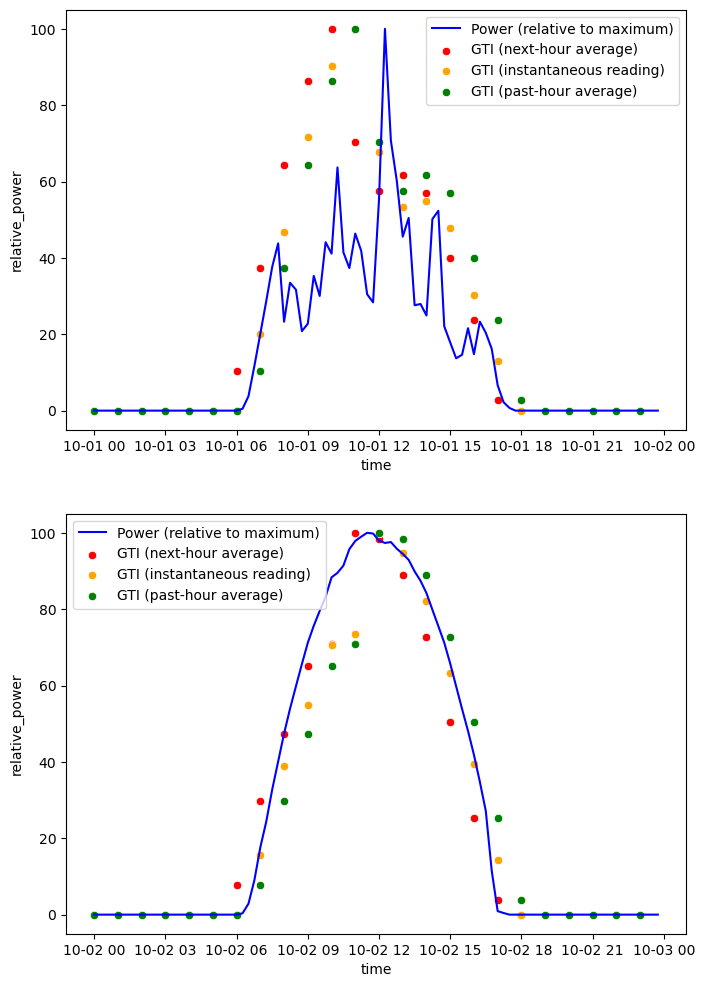

In [240]:
fig = graph_several_days_c(system_4_raw_df, hourly_dataframe, False, date(2007,10,1), date(2007,10,2))
plt.show()

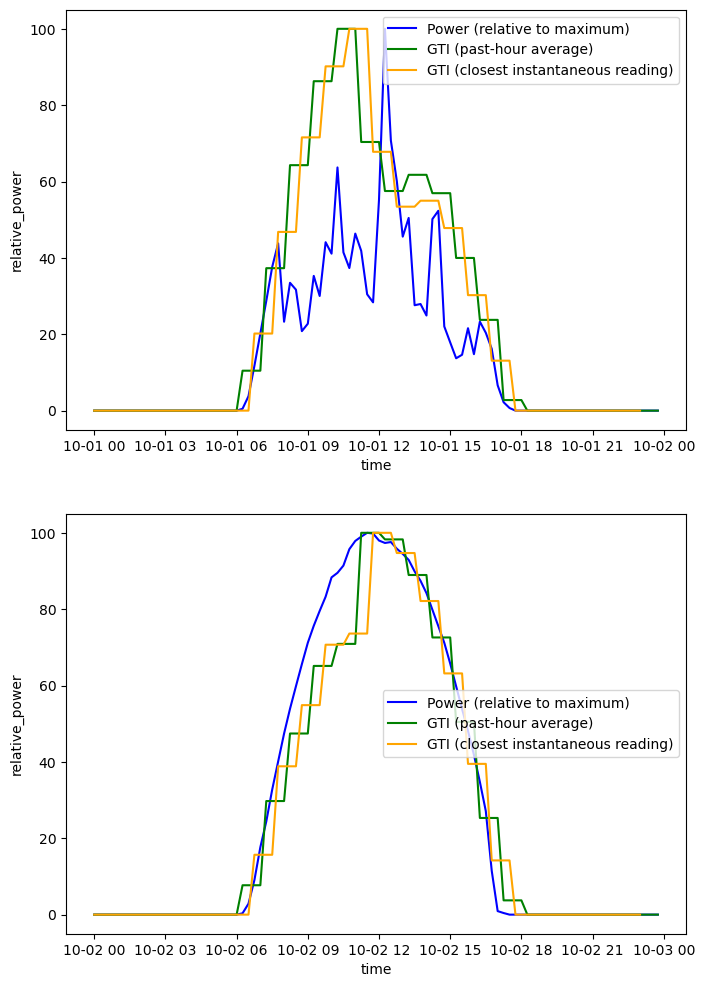

In [239]:
fig = graph_several_days_c(system_4_raw_df, hourly_dataframe, True, date(2007,10,1), date(2007,10,2))
plt.show()